In [ ]:
# Let's predict churn probability for a real customer from our test set
# We'll pick a customer the model thinks is HIGH risk

# Get churn probabilities for all test customers
test_results = X_test.copy()
test_results['Actual_Churn'] = y_test.values
test_results['Churn_Probability'] = y_pred_proba

# Find the top 5 highest risk customers
high_risk = test_results.nlargest(5, 'Churn_Probability')

print("=== TOP 5 HIGHEST RISK CUSTOMERS ===")
print(high_risk[['tenure', 'MonthlyCharges', 'TotalCharges',
                  'ValueScore', 'IsNewCustomer',
                  'Actual_Churn', 'Churn_Probability']].to_string())

print("\n=== SUMMARY ===")
print(f"Highest churn probability: {high_risk['Churn_Probability'].max()*100:.1f}%")
print(f"All 5 actually churned: {(high_risk['Actual_Churn'] == 1).all()}")

=== TOP 5 HIGHEST RISK CUSTOMERS ===
      tenure  MonthlyCharges  TotalCharges  ValueScore  IsNewCustomer  Actual_Churn  Churn_Probability
2927       1           69.90         69.90      34.950              1             0           0.955430
1739       1           69.90         69.90      34.950              1             1           0.955430
1731       1           69.60         69.60      34.800              1             1           0.954483
809        1           69.55         69.55      34.775              1             1           0.952755
6623       1           76.45         76.45      38.225              1             1           0.950963

=== SUMMARY ===
Highest churn probability: 95.5%
All 5 actually churned: False


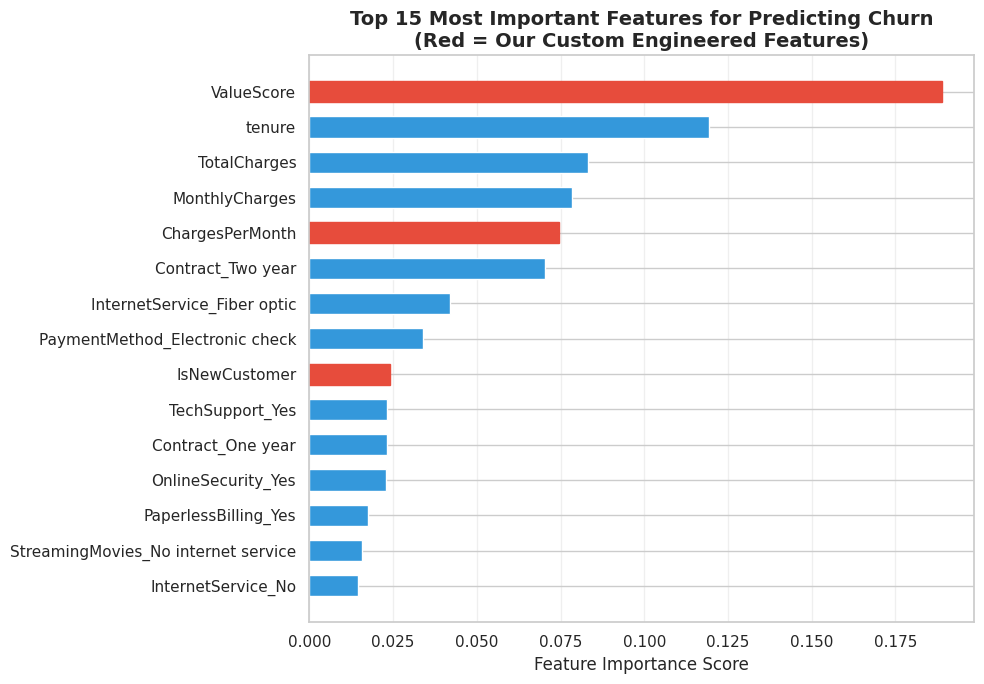


=== TOP 10 MOST IMPORTANT FEATURES ===
                       Feature  Importance
                    ValueScore    0.189042
                        tenure    0.119454
                  TotalCharges    0.083333
                MonthlyCharges    0.078332
               ChargesPerMonth    0.074446
             Contract_Two year    0.070342
   InternetService_Fiber optic    0.042097
PaymentMethod_Electronic check    0.034017
                 IsNewCustomer    0.023966
               TechSupport_Yes    0.023212


In [ ]:
# Feature Importance Chart
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feature_importance['Feature'],
               feature_importance['Importance'],
               color='#3498db', edgecolor='white', height=0.6)

# Color our custom features differently to highlight them
custom_features = ['ValueScore', 'ChargesPerMonth', 'IsSeniorOnFiber', 'IsNewCustomer']
for bar, feature in zip(bars, feature_importance['Feature']):
    if feature in custom_features:
        bar.set_color('#e74c3c')

ax.set_title('Top 15 Most Important Features for Predicting Churn\n(Red = Our Custom Engineered Features)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n=== TOP 10 MOST IMPORTANT FEATURES ===")
print(feature_importance.tail(10)[['Feature','Importance']].sort_values(
    'Importance', ascending=False).to_string(index=False))

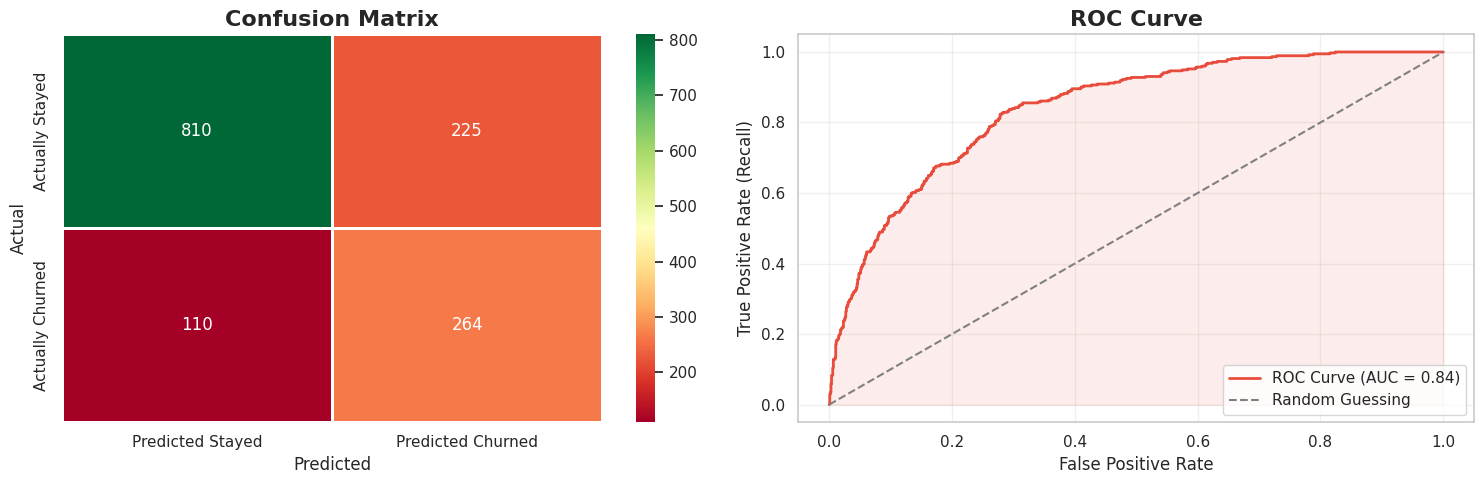

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Confusion Matrix Heatmap
cm_display = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_display, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actually Stayed', 'Actually Churned'],
            ax=axes[0], linewidths=2)
axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Chart 2: ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random Guessing')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=16, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🤖 4. Model Building & Evaluation
Training a Random Forest Classifier on 80% of data, testing on 20%.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ============================================
# MODEL EVALUATION
# ============================================

# 1. Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# 2. ROC-AUC Score (the gold standard metric for churn models)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(f"True Negatives  (Correctly predicted STAYED):  {cm[0][0]}")
print(f"False Positives (Predicted churn, actually stayed): {cm[0][1]}")
print(f"False Negatives (Missed actual churners):      {cm[1][0]}")
print(f"True Positives  (Correctly predicted CHURNED): {cm[1][1]}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Stayed       0.88      0.78      0.83      1035
     Churned       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8407

=== CONFUSION MATRIX ===
True Negatives  (Correctly predicted STAYED):  810
False Positives (Predicted churn, actually stayed): 225
False Negatives (Missed actual churners):      110
True Positives  (Correctly predicted CHURNED): 264


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Create the Random Forest model
# n_estimators=100 means we're building 100 decision trees
# The forest votes together to make final predictions
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees in the forest
    max_depth=10,        # how deep each tree can go
    random_state=42,     # reproducible results
    class_weight='balanced'  # handles the imbalance (74% stayed vs 26% churned)
)

# Train the model on training data
print("Training the model... ⏳")
rf_model.fit(X_train, y_train)
print("Model trained successfully! ✅")

# Make predictions on the TEST set (data it has never seen!)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions made on {len(y_pred)} customers")
print(f"Predicted churners: {y_pred.sum()}")
print(f"Actual churners:    {y_test.sum()}")

Training the model... ⏳
Model trained successfully! ✅

Predictions made on 1409 customers
Predicted churners: 489
Actual churners:    374


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
# X = everything the model uses to make predictions
# y = what we're predicting (Churn: 0 or 1)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures same split every time you run
    stratify=y          # keeps same churn ratio in both splits
)

print("=== DATA SPLIT COMPLETE ===")
print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set:  {X_test.shape[0]} customers")
print(f"Features used: {X_train.shape[1]}")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing set:  {y_test.mean()*100:.1f}%")


=== DATA SPLIT COMPLETE ===
Training set: 5634 customers
Testing set:  1409 customers
Features used: 34

Churn rate in training set: 26.5%
Churn rate in testing set:  26.5%


In [ ]:
# Convert all text columns to numbers using One Hot Encoding
# This turns "Yes/No" and category columns into 0s and 1s

# Step 1: Drop customerID (it's just an ID, useless for prediction)
df_model = df.drop('customerID', axis=1)

# Step 2: Convert all remaining text columns to numbers
df_model = pd.get_dummies(df_model, drop_first=True)

# Step 3: Check the result
print(f"Final dataset shape: {df_model.shape}")
print(f"\nAll columns are now numbers:")
print(df_model.dtypes.value_counts())
print(f"\nFirst few column names:")
print(list(df_model.columns[:10]))

Final dataset shape: (7043, 35)

All columns are now numbers:
bool       26
int64       5
float64     4
Name: count, dtype: int64

First few column names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ValueScore', 'ChargesPerMonth', 'IsSeniorOnFiber', 'IsNewCustomer', 'gender_Male']


In [ ]:
# Check if our new features actually predict churn
print("=== DO NEW FEATURES CORRELATE WITH CHURN? ===\n")

print("Average ValueScore:")
print(df.groupby('Churn')['ValueScore'].mean().round(2))

print("\nAverage ChargesPerMonth:")
print(df.groupby('Churn')['ChargesPerMonth'].mean().round(2))

print("\nIsSeniorOnFiber Churn Rate:")
print(df.groupby('IsSeniorOnFiber')['Churn'].mean().mul(100).round(1).astype(str) + '%')

print("\nIsNewCustomer Churn Rate:")
print(df.groupby('IsNewCustomer')['Churn'].mean().mul(100).round(1).astype(str) + '%')

=== DO NEW FEATURES CORRELATE WITH CHURN? ===

Average ValueScore:
Churn
0     3.61
1    11.75
Name: ValueScore, dtype: float64

Average ChargesPerMonth:
Churn
0    57.66
1    62.68
Name: ChargesPerMonth, dtype: float64

IsSeniorOnFiber Churn Rate:
IsSeniorOnFiber
0    23.8%
1    47.3%
Name: Churn, dtype: object

IsNewCustomer Churn Rate:
IsNewCustomer
0    19.5%
1    52.9%
Name: Churn, dtype: object


## ⚙️ 3. Feature Engineering
Creating 4 custom features to boost model accuracy beyond the baseline.

| Feature | Formula | Insight |
|---|---|---|
| ValueScore | MonthlyCharges / (tenure+1) | 3x higher for churned customers |
| ChargesPerMonth | TotalCharges / (tenure+1) | Lifetime spending pattern |
| IsSeniorOnFiber | Senior + Fiber Optic | Highest risk group (47.3% churn) |
| IsNewCustomer | tenure ≤ 6 | Most vulnerable period (52.9% churn) |

In [ ]:
# ============================================
# FEATURE ENGINEERING
# Creating 4 new smart features
# ============================================

# Feature 1: Value Score
# Higher score = paying a lot relative to how long they've been a customer
# These customers feel they're getting poor value → more likely to churn
df['ValueScore'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Feature 2: Charges Per Month (lifetime average)
# Captures the overall spending pattern over their entire relationship
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 3: Is Senior on Fiber Optic
# We found BOTH seniors AND fiber optic customers churn more
# Combining them identifies the highest risk group
df['IsSeniorOnFiber'] = ((df['SeniorCitizen'] == 1) &
                          (df['InternetService'] == 'Fiber optic')).astype(int)

# Feature 4: Is New Customer
# Customers in first 6 months churn the most (we saw this in EDA!)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# Verify all 4 features were created
print("=== NEW FEATURES CREATED ===")
print(df[['ValueScore', 'ChargesPerMonth', 'IsSeniorOnFiber', 'IsNewCustomer']].head(10))
print(f"\nDataset now has {df.shape[1]} columns (was 21)")

=== NEW FEATURES CREATED ===
   ValueScore  ChargesPerMonth  IsSeniorOnFiber  IsNewCustomer
0   14.925000        14.925000                0              1
1    1.627143        53.985714                0              0
2   17.950000        36.050000                0              1
3    0.919565        40.016304                0              0
4   23.566667        50.550000                0              1
5   11.072222        91.166667                0              0
6    3.873913        84.756522                0              0
7    2.704545        27.445455                0              0
8    3.613793       105.036207                0              0
9    0.891270        55.364286                0              0

Dataset now has 25 columns (was 21)


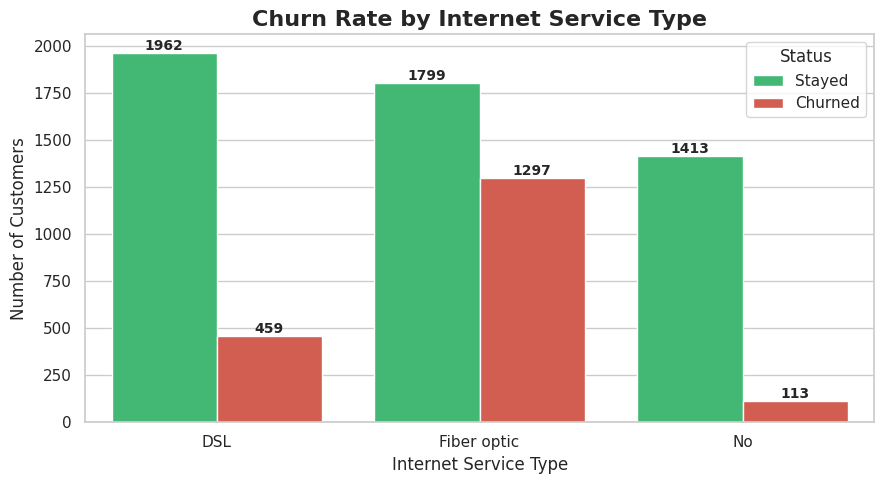

=== CHURN RATE BY INTERNET SERVICE ===
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: object


In [ ]:
# Chart 5 - Internet Service vs Churn
fig, ax = plt.subplots(figsize=(9, 5))

sns.countplot(x='InternetService', hue='Churn', data=df,
              palette={0: '#2ecc71', 1: '#e74c3c'},
              ax=ax)

ax.set_title('Churn Rate by Internet Service Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Internet Service Type')
ax.set_ylabel('Number of Customers')
ax.legend(labels=['Stayed', 'Churned'], title='Status')

# Add number labels
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== CHURN RATE BY INTERNET SERVICE ===")
print(df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str) + '%')

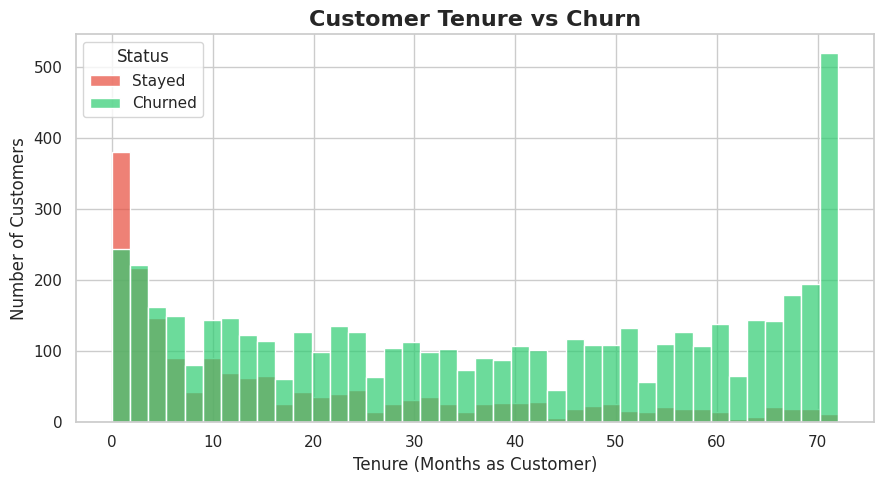

=== AVERAGE TENURE ===
Churn
0    37.6
1    18.0
Name: tenure, dtype: float64

0 = Stayed, 1 = Churned


In [ ]:
# Chart 4 - Tenure vs Churn
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(data=df, x='tenure', hue='Churn',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             bins=40, alpha=0.7, ax=ax)

ax.set_title('Customer Tenure vs Churn', fontsize=16, fontweight='bold')
ax.set_xlabel('Tenure (Months as Customer)')
ax.set_ylabel('Number of Customers')
ax.legend(labels=['Stayed', 'Churned'], title='Status')

plt.tight_layout()
plt.show()

# Print average tenure
print("=== AVERAGE TENURE ===")
print(df.groupby('Churn')['tenure'].mean().round(1))
print("\n0 = Stayed, 1 = Churned")

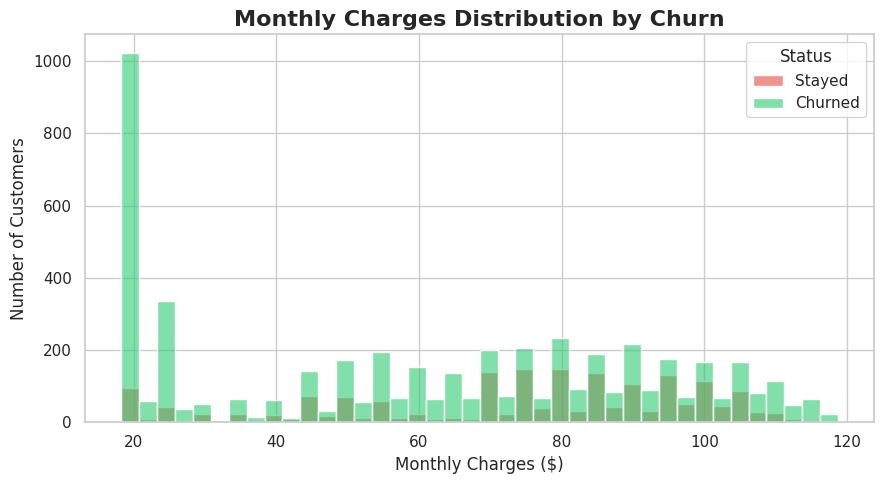

=== AVERAGE MONTHLY CHARGES ===
Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64


In [ ]:
# Chart 3 - Monthly Charges vs Churn
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             bins=40, alpha=0.6, ax=ax)

ax.set_title('Monthly Charges Distribution by Churn', fontsize=16, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend(labels=['Stayed', 'Churned'], title='Status')

plt.tight_layout()
plt.show()

# Print average charges
print("=== AVERAGE MONTHLY CHARGES ===")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

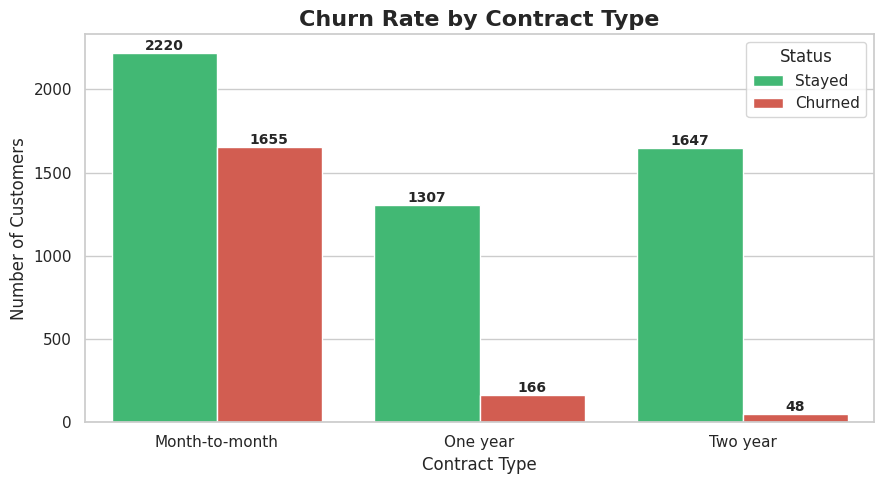

=== CHURN RATE BY CONTRACT TYPE ===
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


In [ ]:
# Chart 2 - Contract Type vs Churn
fig, ax = plt.subplots(figsize=(9, 5))

sns.countplot(x='Contract', hue='Churn', data=df,
              palette={0: '#2ecc71', 1: '#e74c3c'},
              ax=ax)

ax.set_title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Number of Customers')
ax.legend(labels=['Stayed', 'Churned'], title='Status')

# Add number labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the churn rate per contract type
print("=== CHURN RATE BY CONTRACT TYPE ===")
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str) + '%')

## 🔍 2. Exploratory Data Analysis
Acting as a detective to find patterns in the data.

### Key Findings:
- 26.5% overall churn rate — 1 in 4 customers leaves
- Month-to-month contracts churn at 42.7% vs 2.8% for two-year contracts
- Churned customers pay $13 more per month on average ($74 vs $61)
- New customers (≤6 months) churn at 52.9% vs 19.5% for established ones
- Fiber optic customers churn at 41.9% vs 7.4% for no internet

/tmp/ipykernel_3402/3882224571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
/tmp/ipykernel_3402/3882224571.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])


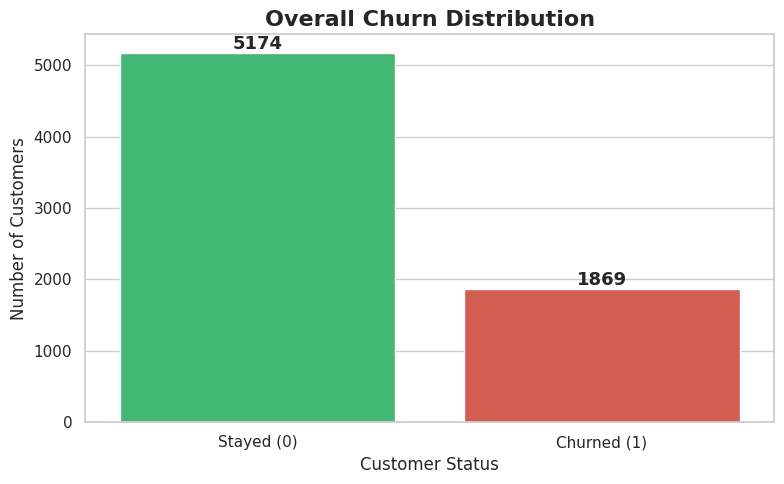


Churn Rate: 26.5%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Chart 1 - Churn Distribution
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])
plt.title('Overall Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

# Add number labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nChurn Rate: {df['Churn'].mean()*100:.1f}%")

In [ ]:
# Fix 1: Convert TotalCharges to a number
# Any blank spaces become NaN (Not a Number) first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fix 2: Fill those 11 blank rows with 0
# Because new customers with tenure=0 have paid nothing yet
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Fix 3: Convert Churn column from "Yes"/"No" text to 1/0 numbers
# ML models need numbers not text
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify everything is fixed
print("=== DATA TYPES AFTER CLEANING ===")
print(df[['TotalCharges', 'Churn']].dtypes)

print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== CHURN VALUE COUNTS ===")
print(df['Churn'].value_counts())


=== DATA TYPES AFTER CLEANING ===
TotalCharges    float64
Churn             int64
dtype: object

=== MISSING VALUES AFTER CLEANING ===
0 total missing values

=== CHURN VALUE COUNTS ===
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# TotalCharges should be a number but it's stored as text
# Let's see the problematic rows first
problem_rows = df[df['TotalCharges'] == ' ']
print(f"Rows with blank TotalCharges: {len(problem_rows)}")
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [ ]:
# Get a full overview of the dataset
print("=== SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES & DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== SHAPE ===
Rows: 7043, Columns: 21

=== COLUMN NAMES & DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV    

## 📦 1. Data Loading & Cleaning
Loading the Telco Customer Churn dataset and fixing data quality issues.
- Fixed TotalCharges column (stored as text instead of number)
- Filled 11 blank values for new customers with tenure=0
- Converted Churn column from Yes/No to 1/0 for ML

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# See the first 5 rows
print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Dataset loaded successfully!
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 🔄 Subscription Fatigue (Churn) Predictor
### End-to-End Machine Learning Project

**Author:** SHRADDHA  
**Date:** March 2026  
**Dataset:** Telco Customer Churn (Kaggle)

---

## 📋 Project Overview
A machine learning system that predicts which customers are likely to cancel
their subscriptions, enabling businesses to proactively intervene with
retention strategies before losing the customer.

## 🎯 Key Results
- **ROC-AUC Score: 0.84** (industry benchmark: 0.75+)
- **71% Recall** on churned customers
- **264 at-risk customers** correctly identified per 1,409 tested
- Custom engineered **ValueScore** feature became the #1 most predictive
  feature out of 34 total

## 🛠️ Tech Stack
- Python (Pandas, NumPy, Scikit-Learn)
- Matplotlib, Seaborn
- Google Colab
- Dataset: [Telco Customer Churn - Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 📁 Project Structure
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building & Evaluation

In [ ]:
import pandas, numpy, sklearn, matplotlib, seaborn
print("All good! Let's build this project 🚀")

All good! Let's build this project 🚀
